# RepSeq bcr trees DEMO 

Data for this tutorial can be fount at https://mixcr.com/mixcr/guides/b-cell-lineages-webinar/

# Preparations 

## Imports

### Basic imports

In [2]:
import os
import pandas as pd
from pandas.api.types import CategoricalDtype

### RepSeq import

In [309]:
from repseq import mixcr as mx
from repseq import io as repseqio
from repseq import plot as rsplot
from repseq import bcr
from repseq import diff_enrichment as rsde
from repseq import clonosets as cl
from repseq import stats

In [388]:
import importlib
importlib.reload(bcr)

<module 'repseq.bcr' from '/home/mmyshkin/soft/repseq/repseq/bcr.py'>

In [376]:
import importlib
importlib.reload(rsplot)

<module 'repseq.plot' from '/home/mmyshkin/soft/repseq/repseq/plot.py'>

## Path to MiXCR binary

In [12]:
MIXCR_PATH = "/home/mmyshkin/soft/mixcr/mixcr"

## Set main folders

In [ ]:
RAW_DATA_DIR = "/home/mmyshkin/raw/dchu_b_cell_lineage/"
WORKING_DIR = "/home/mmyshkin/projects/repseq/bcr_trees"

MIXCR_DIR = os.path.join(WORKING_DIR, "mixcr")
MIXCR_ALLELES_DIR = os.path.join(WORKING_DIR, "mixcr_alleles")
RESULTS_DIR = os.path.join(WORKING_DIR, "results")
TREES_DIR = os.path.join(WORKING_DIR, "trees")

SAMPLE_LIST_FILENAME = os.path.join(WORKING_DIR, "sample_table.csv")
TABLE_REPORT_FILENAME = os.path.join(WORKING_DIR, "table_report.csv")

In [ ]:
# creates directory if it doesn't exist
os.makedirs(WORKING_DIR, exist_ok=True)

## Prepare sample_df

### Create sample_df from scratch

In [239]:
# find all files containing "R1" in their name - you can tweak the substring to match your files.
# The R1 requirement lists only one of the two files so you have a single entry for each sample
filenames = [f for f in os.listdir(RAW_DATA_DIR) if "R1" in f]

# create dataframe with R1 filenames
sample_df = pd.DataFrame(filenames, columns=["R1"])

# parse the sample_id's from R1 samples by splitting and connecting '_' underscores
sample_df["sample_id"] = sample_df["R1"].apply(lambda x: x.split("_R1")[0])

# make full path from R1 filename
sample_df["R1"] = sample_df["R1"].apply(lambda x: os.path.join(RAW_DATA_DIR, x))

# make full path to R2 by replacing
sample_df["R2"] = sample_df["R1"].apply(lambda x: x.replace("_R1", "_R2"))

# subset columns if needed
sample_df = sample_df[["sample_id", "R1", "R2"]]

# extract data from sample_id
sample_df["timepoint"] = sample_df["sample_id"].apply(lambda x: x.split("_")[1])
sample_df["description"] = sample_df["sample_id"].apply(lambda x: x.split("_")[3])
sample_df["source"] = sample_df["sample_id"].apply(lambda x: x.split("_")[2])
sample_df["replica"] = sample_df["sample_id"].apply(lambda x: x.split("_")[-1])
sample_df["donor_id"] = sample_df["sample_id"].apply(lambda x: x.split("_")[0])

timepoint_groups = pd.DataFrame([["T1", "pre"], ["T3", "pre"], ["T5", "pre"], ["T6", "pre"],
                                 ["T2", "post"], ["T4", "post"], ["T7", "post"], ["T8", "post"]],
                                columns=["timepoint", "group"]
                               )
sample_df = sample_df.merge(timepoint_groups)

# sort samples
sample_df = sample_df.sort_values(by=["timepoint", "source", "replica"]).reset_index(drop=True)

sample_df

,sample_id,R1,R2,timepoint,description,source,replica,donor_id,group
0,DChu_T1_pbmc_H_1,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T1...,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T1...,T1,H,pbmc,1,DChu,pre
1,DChu_T1_pbmc_H_2,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T1...,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T1...,T1,H,pbmc,2,DChu,pre
2,DChu_T2_pbmc_beforeSV2_1,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T2...,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T2...,T2,beforeSV2,pbmc,1,DChu,post
3,DChu_T2_pbmc_beforeSV2_2,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T2...,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T2...,T2,beforeSV2,pbmc,2,DChu,post
4,DChu_T3_pbmc_preCOVID_1,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T3...,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T3...,T3,preCOVID,pbmc,1,DChu,pre
5,DChu_T3_pbmc_preCOVID_2,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T3...,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T3...,T3,preCOVID,pbmc,2,DChu,pre
6,DChu_T4_Bmem_postCOVID_1,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T4...,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T4...,T4,postCOVID,Bmem,1,DChu,post
7,DChu_T4_asc_postCOVID_1,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T4...,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T4...,T4,postCOVID,asc,1,DChu,post
8,DChu_T4_pbmc_postCOVID_1,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T4...,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T4...,T4,postCOVID,pbmc,1,DChu,post
9,DChu_T5_pbmc_H_1,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T5...,/home/mmyshkin/raw/dchu_b_cell_lineage/DChu_T5...,T5,H,pbmc,1,DChu,pre


In [61]:
sample_df.to_csv(SAMPLE_LIST_FILENAME, index=False)
print(f"SAMPLE list saved to: {SAMPLE_LIST_FILENAME}")

SAMPLE list saved to: /home/mmyshkin/projects/repseq/bcr_trees/sample_table.csv


In [240]:
metadata = sample_df.drop(columns=["R1", "R2"])
metadata

,sample_id,timepoint,description,source,replica,donor_id,group
0,DChu_T1_pbmc_H_1,T1,H,pbmc,1,DChu,pre
1,DChu_T1_pbmc_H_2,T1,H,pbmc,2,DChu,pre
2,DChu_T2_pbmc_beforeSV2_1,T2,beforeSV2,pbmc,1,DChu,post
3,DChu_T2_pbmc_beforeSV2_2,T2,beforeSV2,pbmc,2,DChu,post
4,DChu_T3_pbmc_preCOVID_1,T3,preCOVID,pbmc,1,DChu,pre
5,DChu_T3_pbmc_preCOVID_2,T3,preCOVID,pbmc,2,DChu,pre
6,DChu_T4_Bmem_postCOVID_1,T4,postCOVID,Bmem,1,DChu,post
7,DChu_T4_asc_postCOVID_1,T4,postCOVID,asc,1,DChu,post
8,DChu_T4_pbmc_postCOVID_1,T4,postCOVID,pbmc,1,DChu,post
9,DChu_T5_pbmc_H_1,T5,H,pbmc,1,DChu,pre


## Make up MiXCR command template

For this dataset we used `LLC MiLaboratory 5'RACE TCR Kit Human` and here is the command template for it (`-f` is useful flag for rerunning your preprocessing):

In [32]:
mixcr_human_bcr_multiplex_command_template = "mixcr analyze milab-human-rna-ig-umi-multiplex -f r1 r2 output_prefix"

# RUN! MiXCR

Now that we have prepared everything: `sample_df`, `MIXCR_PATH`, `MIXCR_DIR_SLURM`, `mixcr_race_command_template`

We can now run MiXCR!

## Using SLURM queue manager

Our computational cluster Aldan3 (link) uses SLURM queue manager. So the first part of the demo will be useful for SLURM users

The following function in its core constructs a MiXCR command for each sample and then automatically creates SLURM .sh scripts for each of the samples so they can be processed in parallel on different nodes. It adds all the given resources requirements to the SLURM script. Then adds all these SLURM jobs to the queue with `sbatch` command.

The scripts are kept in `~/temp/slurm/` folder and have timestamps as well as job_names in their names.

The log files with stdout/stderr MiXCR output can be found in your `output_folder/logs` directory. Check them in case something goes wrong.

In [42]:
mx.mixcr4_analyze_batch(sample_df.iloc[:1],                                        # <- first arg is your sample df. Make sure it contains sample_id, R1 and R2 (full paths) columns 
                        MIXCR_DIR,                                  # <- second arg is output folder (also better use abs path)
                        mixcr_path=MIXCR_PATH,                            # <- path to MIXCR binary
                        command_template=mixcr_human_bcr_multiplex_command_template,     # <- your command template variable. Default is "mixcr analyze milab-human-rna-tcr-umi-multiplex -f r1 r2 output_prefix"
                        backend="slurm",                                  # <- type of backend "slurm" or "local", "local" is default value
                        cpus=40,                                          # <- CPU's - will be added to SLURM .sh script
                        memory=32,                                        # <- RAM in Gb's. Also will be added to SLURM .sh script and -Xmx32g to mixcr command so that Java takes this memory
                        time_estimate=1.5,                                # <- time in hours - will be added to SLURM .sh script
                        custom_tag_pattern_column=None                    # <- If your df contains valid custom tag-patterns for each sample it can be uppended to the command template automatically
                       )

1 tasks added to slurm queue
Logs folder: /home/mmyshkin/projects/repseq/bcr_trees/mixcr/logs
Job table: /home/mmyshkin/projects/repseq/bcr_trees/mixcr/logs/mixcr_analyze_batch_jobs.csv


,jobname,sample_id,backend,job_id,status,returncode,cwd,log_filename,command
0,mixcr_analyze_DChu_T1_pbmc_H_1,DChu_T1_pbmc_H_1,slurm,1427472,submitted,,/home/mmyshkin/projects/repseq/bcr_trees/mixcr,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...


In [45]:
mx.check_batch_progress(MIXCR_DIR, loop=True)

MIXCR4 Analyze Batch |##################################################| 1/1 task(s) processed


In [46]:
mx.check_batch_progress(MIXCR_DIR, loop=False)

                       jobname        sample_id backend  job_id   status  returncode                                                                           log_filename
mixcr_analyze_DChu_T1_pbmc_H_1 DChu_T1_pbmc_H_1   slurm 1427472 finished           0 /home/mmyshkin/projects/repseq/bcr_trees/mixcr/logs/mixcr_analyze_DChu_T1_pbmc_H_1.log
MIXCR4 Analyze Batch |##################################################| 1/1 task(s) processed


In [3]:
pd.read_csv("/home/mmyshkin/projects/repseq/bcr_trees/mixcr/logs/mixcr_analyze_batch_jobs.csv")

,jobname,sample_id,backend,job_id,status,returncode,cwd,log_filename,command
0,mixcr_analyze_DChu_T1_pbmc_H_2,DChu_T1_pbmc_H_2,slurm,1427418,finished,0,/home/mmyshkin/projects/repseq/bcr_trees/mixcr,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
1,mixcr_analyze_DChu_T2_pbmc_beforeSV2_1,DChu_T2_pbmc_beforeSV2_1,slurm,1427419,finished,0,/home/mmyshkin/projects/repseq/bcr_trees/mixcr,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
2,mixcr_analyze_DChu_T2_pbmc_beforeSV2_2,DChu_T2_pbmc_beforeSV2_2,slurm,1427420,finished,0,/home/mmyshkin/projects/repseq/bcr_trees/mixcr,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
3,mixcr_analyze_DChu_T3_pbmc_preCOVID_1,DChu_T3_pbmc_preCOVID_1,slurm,1427421,finished,0,/home/mmyshkin/projects/repseq/bcr_trees/mixcr,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
4,mixcr_analyze_DChu_T3_pbmc_preCOVID_2,DChu_T3_pbmc_preCOVID_2,slurm,1427422,finished,0,/home/mmyshkin/projects/repseq/bcr_trees/mixcr,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
5,mixcr_analyze_DChu_T4_Bmem_postCOVID_1,DChu_T4_Bmem_postCOVID_1,slurm,1427423,finished,0,/home/mmyshkin/projects/repseq/bcr_trees/mixcr,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
6,mixcr_analyze_DChu_T4_asc_postCOVID_1,DChu_T4_asc_postCOVID_1,slurm,1427424,finished,0,/home/mmyshkin/projects/repseq/bcr_trees/mixcr,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
7,mixcr_analyze_DChu_T4_pbmc_postCOVID_1,DChu_T4_pbmc_postCOVID_1,slurm,1427425,finished,0,/home/mmyshkin/projects/repseq/bcr_trees/mixcr,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
8,mixcr_analyze_DChu_T5_pbmc_H_1,DChu_T5_pbmc_H_1,slurm,1427426,finished,0,/home/mmyshkin/projects/repseq/bcr_trees/mixcr,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...
9,mixcr_analyze_DChu_T5_pbmc_H_2,DChu_T5_pbmc_H_2,slurm,1427427,finished,0,/home/mmyshkin/projects/repseq/bcr_trees/mixcr,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g analyz...


# Quality control

## QC images by Repseq - analogs, that are read from `report.json` files

### Align QC

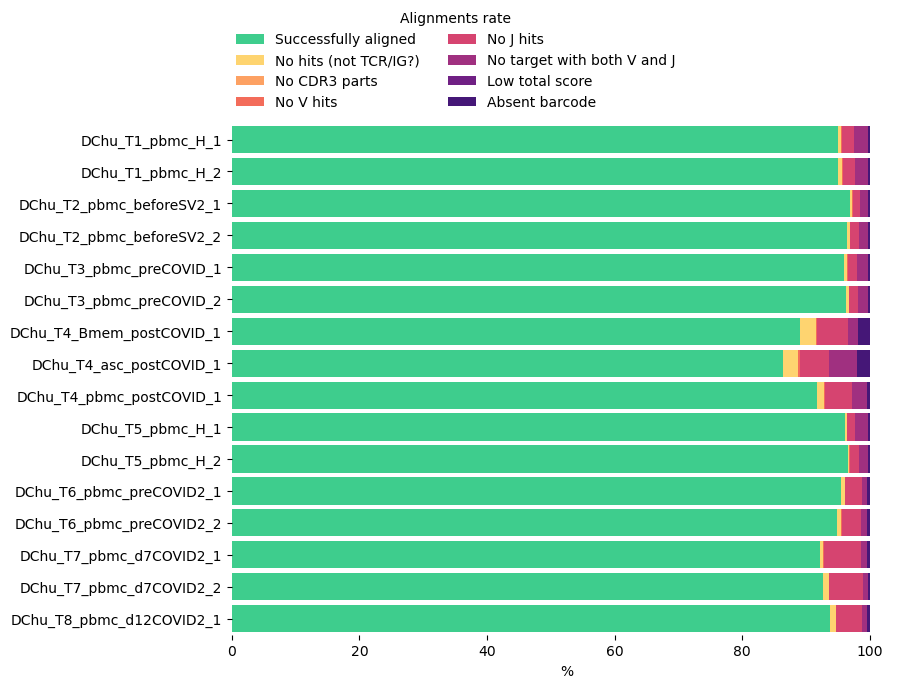

In [47]:
mx.show_qc_plot(MIXCR_DIR, chart_type='align', count_type='percent', output_file=None)

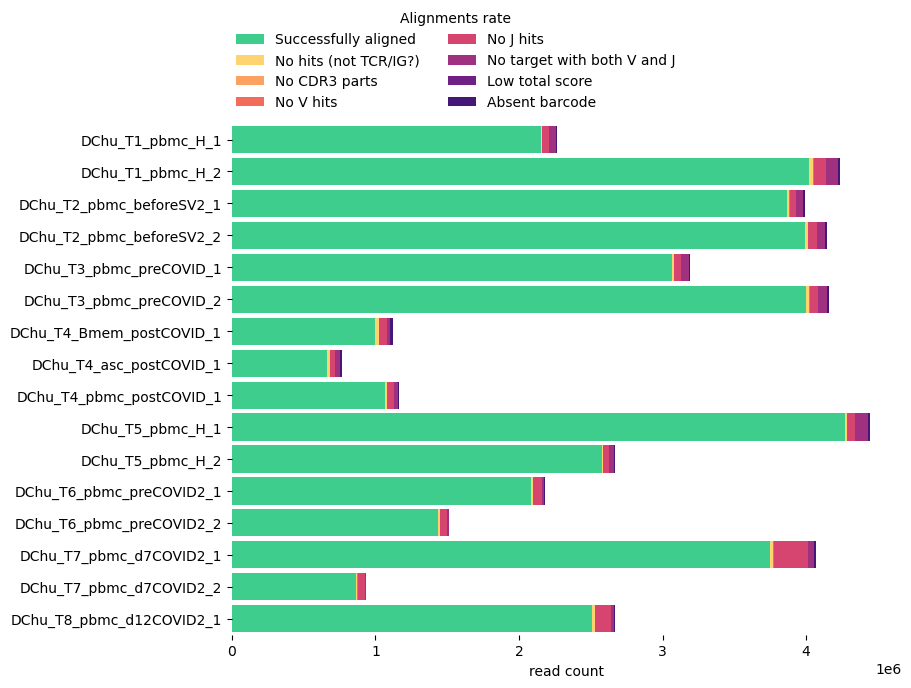

In [48]:
mx.show_qc_plot(MIXCR_DIR, chart_type='align', count_type='abs', output_file=None)

### Chain QC

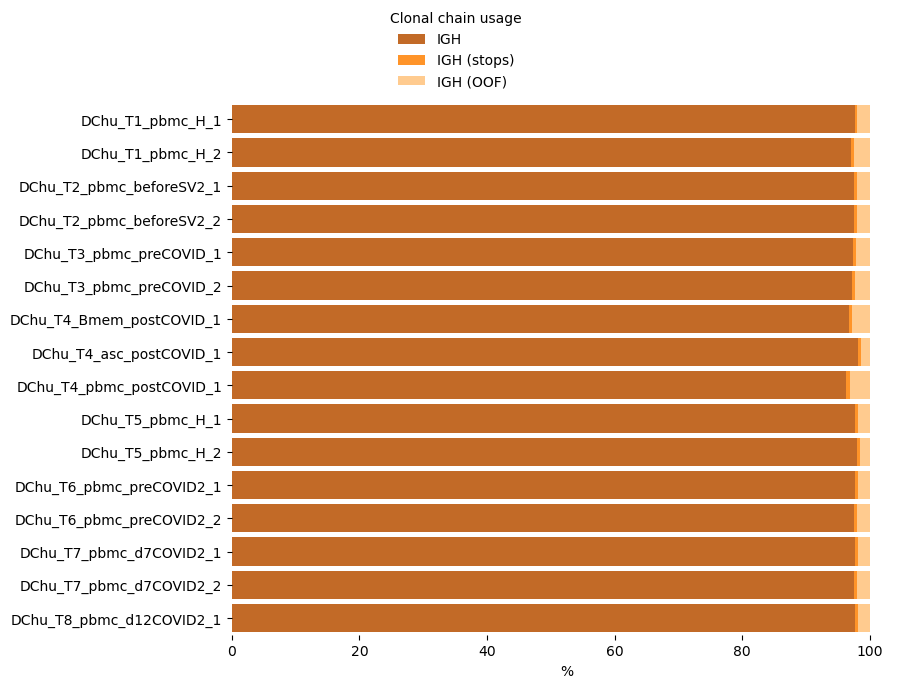

In [49]:
mx.show_qc_plot(MIXCR_DIR, chart_type='chains', count_type='percent', output_file=None)

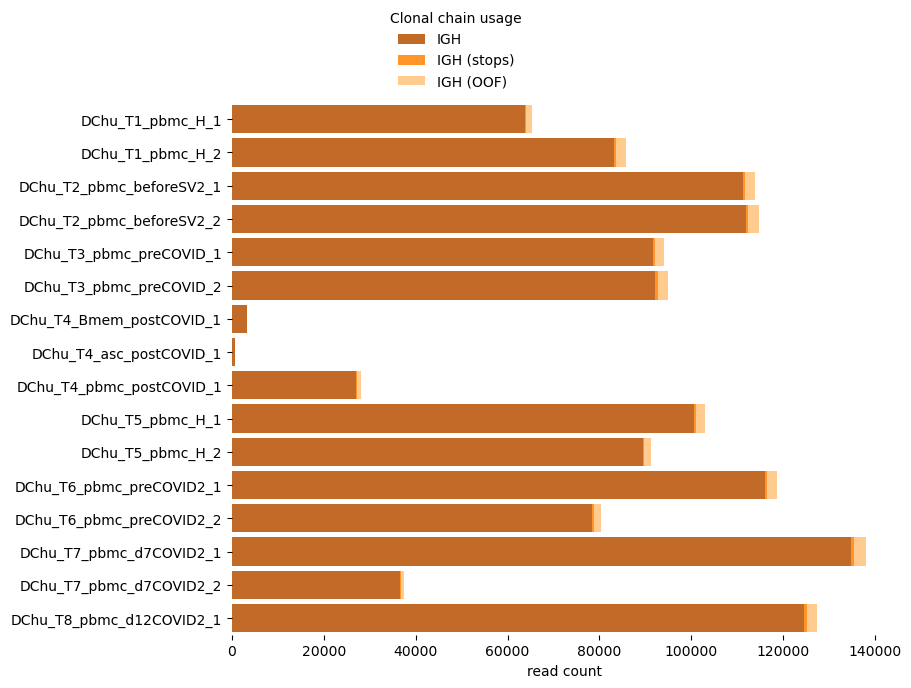

In [50]:
mx.show_qc_plot(MIXCR_DIR, chart_type='chains', count_type='abs', output_file=None)

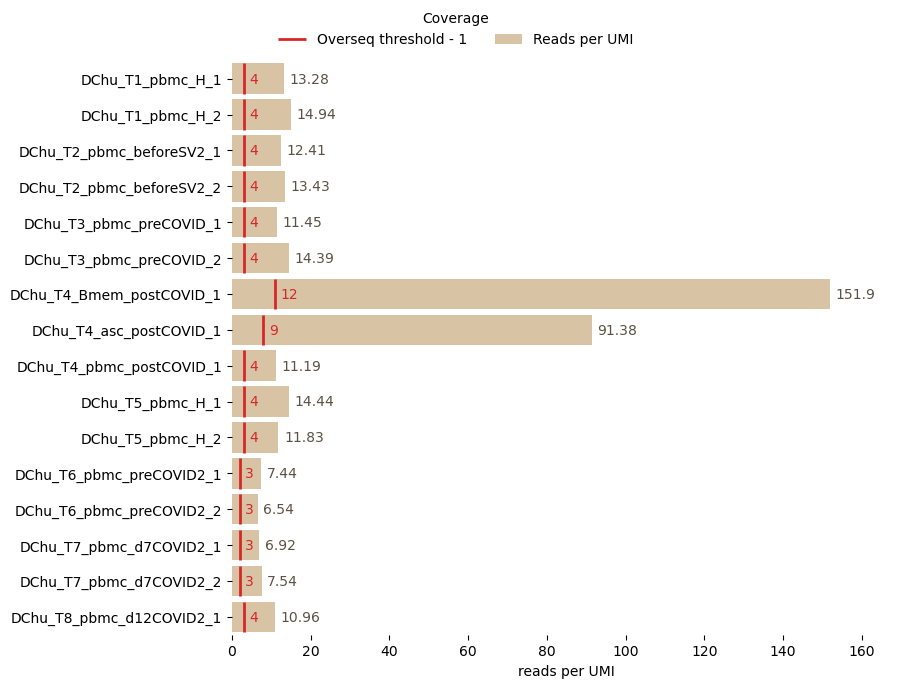

In [51]:
mx.show_qc_plot(MIXCR_DIR, chart_type='coverage', count_type='abs', output_file=None)

## Comprehensive Preprocessing Table

### Get the table

In [52]:
proc_table = mx.get_processing_table(MIXCR_DIR)
proc_table

,sample_id,extracted_chain,reads_total,reads_with_umi_pc,reads_aligned_pc,reads_overlapped_aln_pc,total_umi,umi_after_correction,overseq_threshold,reads_after_filter,umi_after_filter,reads_per_umi,clones_total,reads_in_clones_total,clones,reads_in_clones,clones_func,reads_in_func_clones,umi_in_clones,umi_in_func_clones
0,DChu_T1_pbmc_H_1,IGH,2283571,99.66,94.16,97.01,333569,225368,4,2024550,152482,13.28,65339,1967952,65339,1967952,63542,1940975,154085,151842
1,DChu_T1_pbmc_H_2,IGH,4272245,99.70,94.15,96.65,543157,360442,4,3843613,257189,14.94,85712,3700538,85712,3700538,82834,3652138,263450,259833
2,DChu_T2_pbmc_beforeSV2_1,IGH,4024748,99.70,96.12,97.02,596167,421879,4,3638729,293268,12.41,113908,3484654,113908,3484654,110793,3445862,303323,299746
3,DChu_T2_pbmc_beforeSV2_2,IGH,4174566,99.70,95.67,97.27,588483,402985,4,3778273,281326,13.43,114636,3628501,114636,3628501,111469,3562415,290679,285889
4,DChu_T3_pbmc_preCOVID_1,IGH,3229305,99.70,94.89,96.30,510163,362977,4,2865909,250339,11.45,94027,2752274,94027,2752274,91254,2717762,255235,251916
5,DChu_T3_pbmc_preCOVID_2,IGH,4199241,99.70,95.30,96.84,552130,372448,4,3814070,265051,14.39,94851,3680323,94851,3680323,91857,3630514,272372,268540
6,DChu_T4_Bmem_postCOVID_1,IGH,1134924,98.11,88.01,95.43,55895,25649,12,952398,6270,151.90,3398,936571,3398,936571,3262,913948,6059,5903
7,DChu_T4_asc_postCOVID_1,IGH,777108,98.06,85.32,96.32,54408,29835,9,608402,6658,91.38,775,594303,775,594303,756,589997,6504,6464
8,DChu_T4_pbmc_postCOVID_1,IGH,1178081,99.60,90.58,95.98,166895,135660,4,983039,87861,11.19,28126,959846,28126,959846,26961,944859,87674,86320
9,DChu_T5_pbmc_H_1,IGH,4498501,99.68,94.92,96.28,590619,444840,4,3968736,274793,14.44,103042,3813002,103042,3813002,100281,3767158,281791,278317


In [53]:
proc_table.to_csv(TABLE_REPORT_FILENAME, index=False)
print(f"PREPROCESSING table saved to: {TABLE_REPORT_FILENAME}")

PREPROCESSING table saved to: /home/mmyshkin/projects/repseq/bcr_trees/table_report.csv


In [54]:
mx.get_processing_table(MIXCR_DIR, small=True)

,sample_id,extracted_chain,reads_total,reads_with_umi_pc,reads_aligned_pc,reads_overlapped_aln_pc,reads_per_umi,overseq_threshold,clones_func,umi_in_func_clones
0,DChu_T1_pbmc_H_1,IGH,2283571,99.66,94.16,97.01,13.28,4,63542,151842
1,DChu_T1_pbmc_H_2,IGH,4272245,99.70,94.15,96.65,14.94,4,82834,259833
2,DChu_T2_pbmc_beforeSV2_1,IGH,4024748,99.70,96.12,97.02,12.41,4,110793,299746
3,DChu_T2_pbmc_beforeSV2_2,IGH,4174566,99.70,95.67,97.27,13.43,4,111469,285889
4,DChu_T3_pbmc_preCOVID_1,IGH,3229305,99.70,94.89,96.30,11.45,4,91254,251916
5,DChu_T3_pbmc_preCOVID_2,IGH,4199241,99.70,95.30,96.84,14.39,4,91857,268540
6,DChu_T4_Bmem_postCOVID_1,IGH,1134924,98.11,88.01,95.43,151.90,12,3262,5903
7,DChu_T4_asc_postCOVID_1,IGH,777108,98.06,85.32,96.32,91.38,9,756,6464
8,DChu_T4_pbmc_postCOVID_1,IGH,1178081,99.60,90.58,95.98,11.19,4,26961,86320
9,DChu_T5_pbmc_H_1,IGH,4498501,99.68,94.92,96.28,14.44,4,100281,278317


### Useful plots

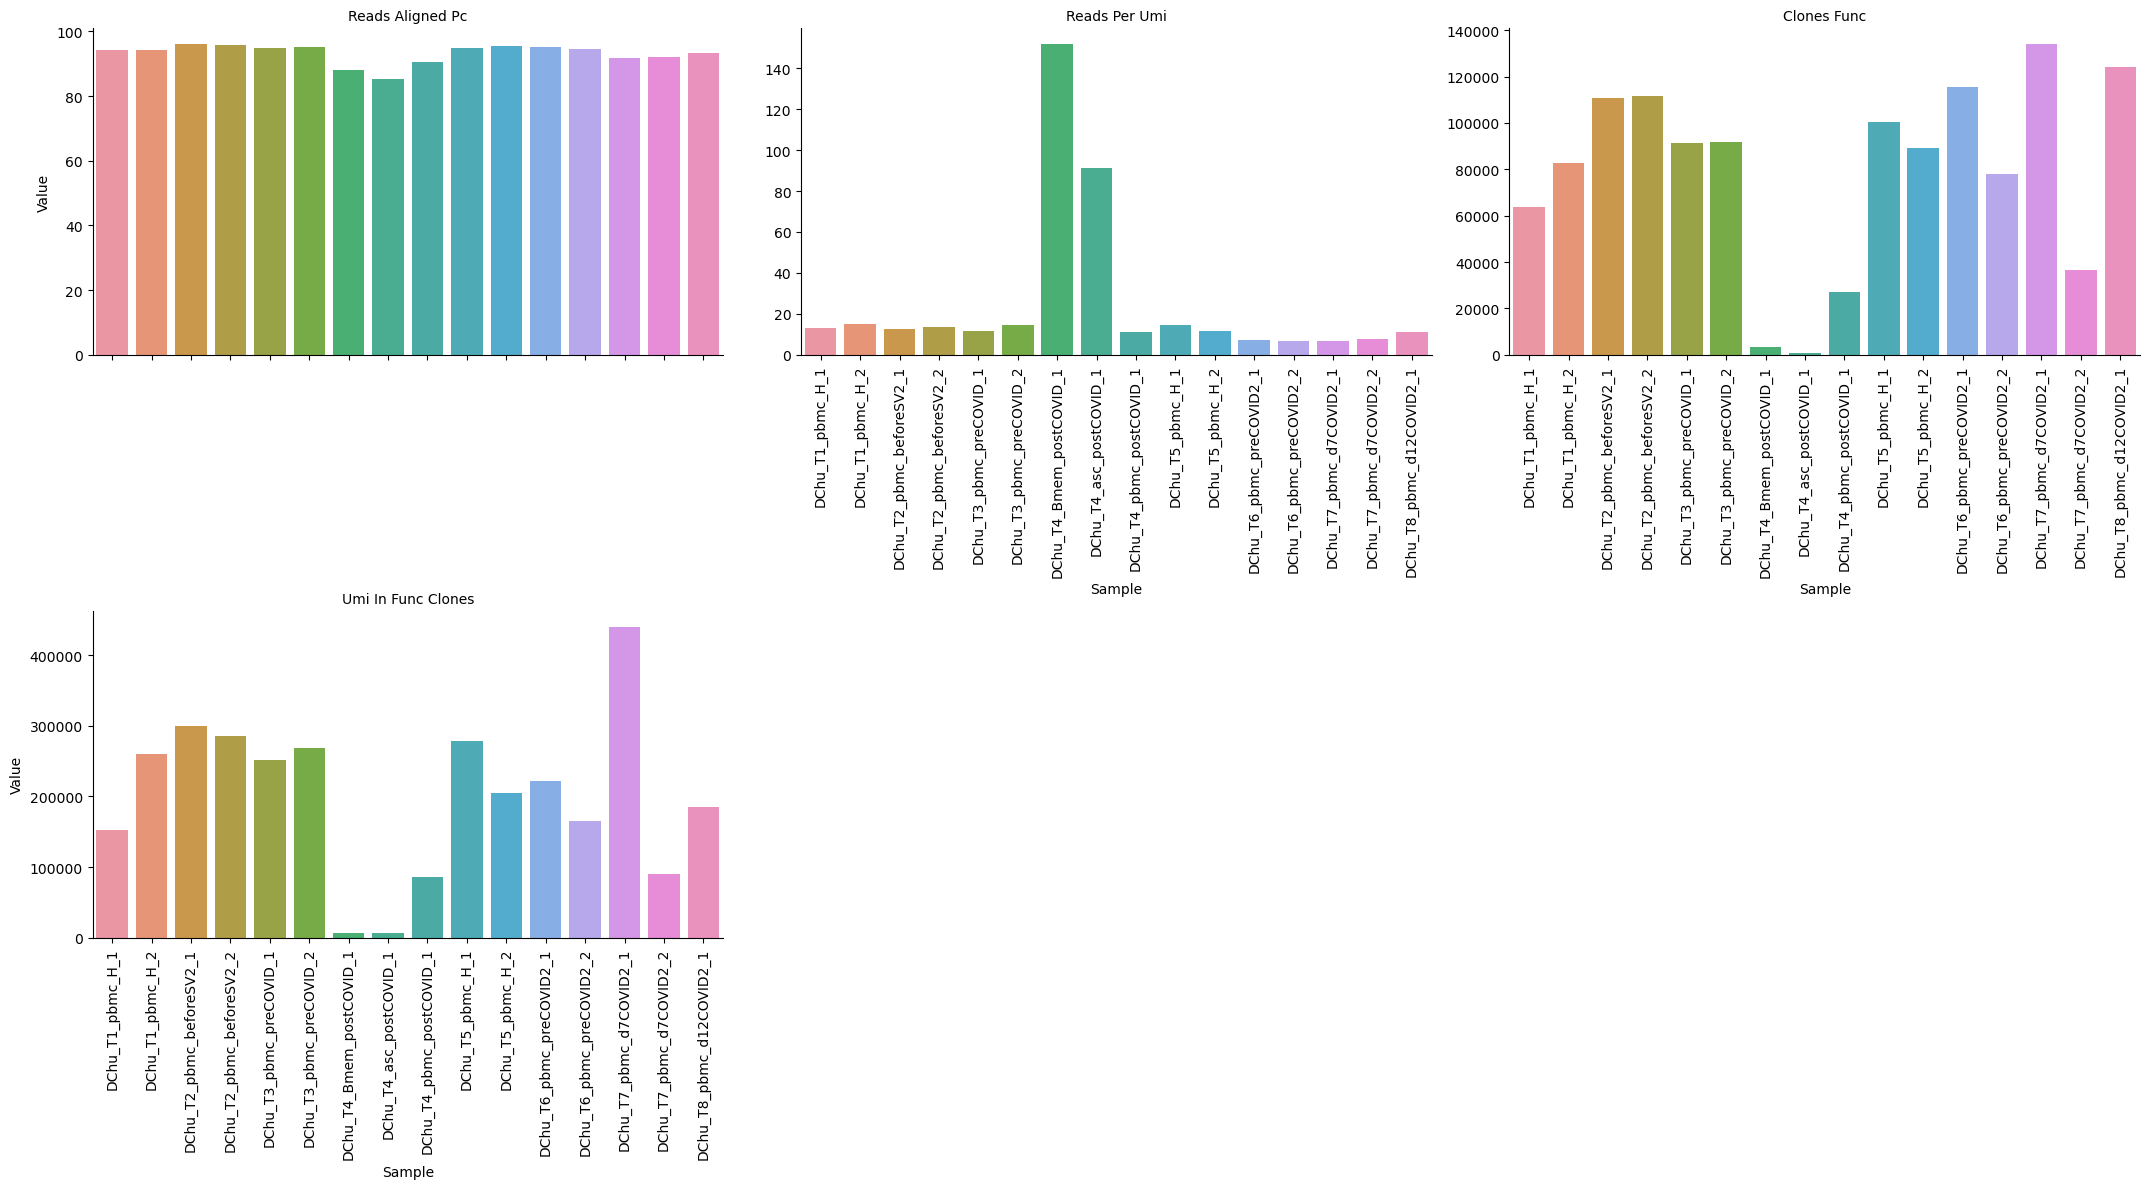

In [57]:
rsplot.processing(proc_table, height=6)

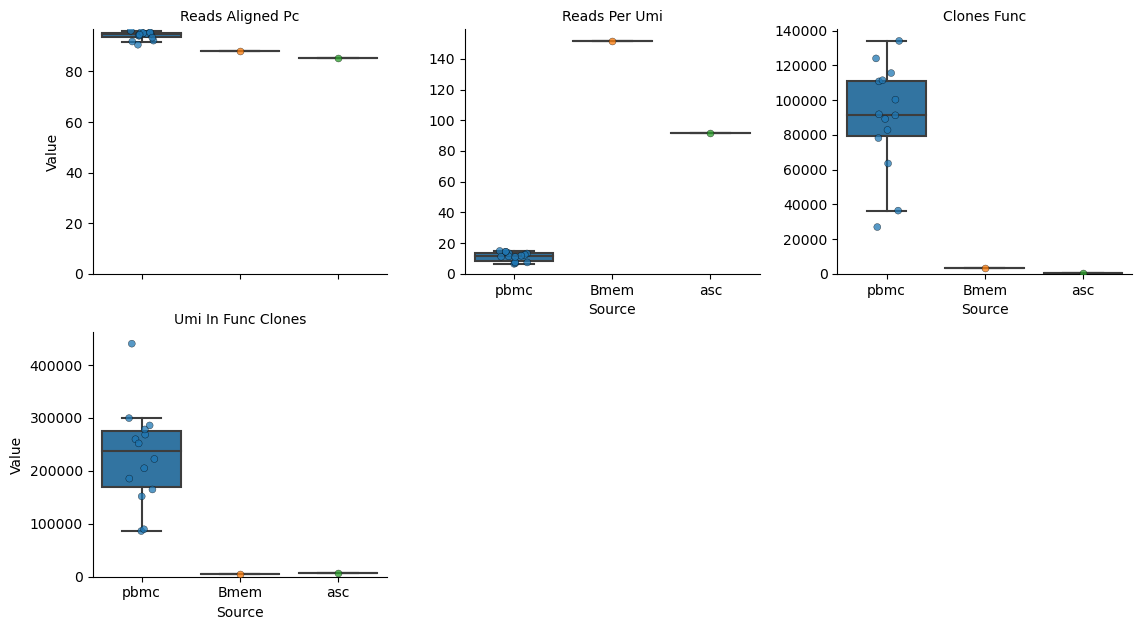

In [56]:
rsplot.processing(proc_table, metadata=metadata, group="source")

# Allele calling

In [63]:
mx.find_alleles(MIXCR_DIR,
                MIXCR_ALLELES_DIR,
                mixcr_path=MIXCR_PATH,
                sample_df=sample_df,
                backend="slurm",
                cpus=4,
                memory=32,
                time_estimate=0.5,
                constraint=None
               )

Donor DChu: 16 .clns file(s)
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr/DChu_T1_pbmc_H_1.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr/DChu_T1_pbmc_H_2.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr/DChu_T2_pbmc_beforeSV2_1.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr/DChu_T2_pbmc_beforeSV2_2.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr/DChu_T3_pbmc_preCOVID_1.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr/DChu_T3_pbmc_preCOVID_2.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr/DChu_T4_Bmem_postCOVID_1.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr/DChu_T4_asc_postCOVID_1.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr/DChu_T4_pbmc_postCOVID_1.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr/DChu_T5_pbmc_H_1.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr/DChu_T5_pbmc_H_2.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr/DChu_T6_pbmc_preCOVID2_1.clns
  - /home/mmyshkin/projects/repseq

,jobname,sample_id,backend,job_id,status,returncode,cwd,log_filename,command
0,mixcr_find_alleles_DChu,DChu,slurm,1427517,submitted,,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,/home/mmyshkin/soft/mixcr/mixcr -Xmx32g findAl...


In [66]:
mx.check_batch_progress(MIXCR_ALLELES_DIR, loop=True, default_filename="find_alleles_batch.log")

MiXCR Find Alleles Batch |##################################################| 1/1 task(s) processed


In [68]:
mx.check_batch_progress(MIXCR_ALLELES_DIR, loop=False, default_filename="find_alleles_batch.log")

                jobname sample_id backend  job_id   status  returncode                                                                            log_filename
mixcr_find_alleles_DChu      DChu   slurm 1427517 finished           0 /home/mmyshkin/projects/repseq/bcr_trees/mixcr_alleles/logs/mixcr_find_alleles_DChu.log
MiXCR Find Alleles Batch |##################################################| 1/1 task(s) processed


# Find Trees

## Run MiXCR

In [84]:
mx.find_shm_trees(MIXCR_ALLELES_DIR,
                  TREES_DIR,
                  mixcr_path=MIXCR_PATH,
                  sample_df=sample_df,
                  backend="slurm", 
                  cpus=10,
                  memory=256,
                  time_estimate=0.5,
                  constraint=None
                 )

Donor DChu: 16 .clns file(s)
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr_alleles/DChu_T1_pbmc_H_1.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr_alleles/DChu_T1_pbmc_H_2.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr_alleles/DChu_T2_pbmc_beforeSV2_1.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr_alleles/DChu_T2_pbmc_beforeSV2_2.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr_alleles/DChu_T3_pbmc_preCOVID_1.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr_alleles/DChu_T3_pbmc_preCOVID_2.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr_alleles/DChu_T4_Bmem_postCOVID_1.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr_alleles/DChu_T4_asc_postCOVID_1.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr_alleles/DChu_T4_pbmc_postCOVID_1.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr_alleles/DChu_T5_pbmc_H_1.clns
  - /home/mmyshkin/projects/repseq/bcr_trees/mixcr_alleles/DChu_T5_pbmc_H_2.clns
  - /home/mmyshkin/projects

,jobname,sample_id,backend,job_id,status,returncode,cwd,log_filename,command
0,mixcr_find_shm_trees_DChu,DChu,slurm,1427737,submitted,,/home/mmyshkin/projects/repseq/bcr_trees/trees,/home/mmyshkin/projects/repseq/bcr_trees/trees...,/home/mmyshkin/soft/mixcr/mixcr -Xmx256g findS...


In [110]:
mx.check_batch_progress(TREES_DIR, loop=True, default_filename="find_shm_trees_batch.log")

MiXCR Find SHM Trees Batch |##################################################| 1/1 task(s) processed


In [109]:
mx.check_batch_progress(TREES_DIR, loop=False, default_filename="find_shm_trees_batch.log")

                  jobname sample_id backend  job_id   status returncode                                                                      log_filename
mixcr_find_shm_trees_DChu      DChu   slurm 1427737 finished          0 /home/mmyshkin/projects/repseq/bcr_trees/trees/logs/mixcr_find_shm_trees_DChu.log
MiXCR Find SHM Trees Batch |##################################################| 1/1 task(s) processed


## Look at the trees df

### Check TREES_DIR contents

In [96]:
!ls {TREES_DIR}

DChu_newick	DChu_trees.shmt  find_shm_trees_batch.log
DChu_trees.log	DChu_trees.tsv	 logs


### Create TreeAnalyzer and read trees table

In [389]:
ta = bcr.TreeAnalyzer()
ta.read_trees_table(os.path.join(TREES_DIR, "DChu_trees.tsv"))

/home/mmyshkin/soft/repseq/repseq/bcr.py:218: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  observed = _observed_mask(self.trees_df)


Pooled 1297166 clonotypes from 16 samples
Read 20439 trees from 16 samples: 154505 nodes, 107051 observed nodes


In [390]:
ta.trees_df.head()

,treeId,nodeId,isObserved,chains,parentId,DistanceFromGermline,nMutationsRate,cloneId,fileName,readCount,...,aaSeqCDR2,aaSeqFR3,aaSeqCDR3,aaSeqFR4,isotype,refPoints,sample_id,newick_filename,uniqueMoleculeCount,uniqueMoleculeFraction
0,1,0,False,IGH,NaN,0.0,0.000000,NaN,NaN,NaN,...,INPNSGGT,NYAQKFQGWVTMTRDTSISTAYMELSRLRSDDTAVYY,CARDQDGSGWSPW,GQGTLVTVSS,NaN,NaN,<NA>,<NA>,<NA>,NaN
1,1,2,True,IGH,0.0,9.0,0.034483,70.0,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,934.0,...,INPNSGGT,KYAQKFQGWITMTGDTSISTAYMELSRLRSDDTAVYY,CARAQDGSGWSHW,GQGTLVTVSS,IgM,:::::0:24:75:99:210:2:223:226:-4:-2:241:244:-1...,DChu_T4_Bmem_postCOVID_1,<NA>,6.0,0.000990
2,1,2,True,IGH,0.0,9.0,0.034483,593.0,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,344.0,...,INPNSGGT,KYAQKFQGWITMTGDTSISTAYMELSRLRSDDTAVYY,CARAQDGSGWSHW,GQGTLVTVSS,IgD,:::::0:24:75:99:210:2:223:226:-4:-2:241:242:-1...,DChu_T4_Bmem_postCOVID_1,<NA>,3.0,0.000495
3,2,0,False,IGH,NaN,0.0,0.000000,NaN,NaN,NaN,...,INPNSGGT,NYAQKFQGWVTMTRDTSISTAYMELSRLRSDDTAVYY,CARGTTVNYGWFDPW,GQGTLVTVSS,NaN,NaN,<NA>,<NA>,<NA>,NaN
4,2,4,False,IGH,0.0,11.0,0.041353,NaN,NaN,NaN,...,INPDSGGS,NYAQKFQGWVTMTRDTSISTAYMEVSRLRSDDTAVYY,CARGTTVNYGWFDPW,GQGTLVTVSS,NaN,NaN,<NA>,<NA>,<NA>,NaN


### Add metadata

In [391]:
ta.read_metadata(metadata)

Metadata updated for 16 samples and 107051 observed nodes


In [392]:
ta.trees_df.head()

,treeId,nodeId,isObserved,chains,parentId,DistanceFromGermline,nMutationsRate,cloneId,fileName,readCount,...,sample_id,newick_filename,uniqueMoleculeCount,uniqueMoleculeFraction,timepoint,description,source,replica,donor_id,group
0,1,0,False,IGH,NaN,0.0,0.000000,NaN,NaN,NaN,...,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,True,IGH,0.0,9.0,0.034483,70.0,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,934.0,...,DChu_T4_Bmem_postCOVID_1,<NA>,6.0,0.000990,T4,postCOVID,Bmem,1,DChu,post
2,1,2,True,IGH,0.0,9.0,0.034483,593.0,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,344.0,...,DChu_T4_Bmem_postCOVID_1,<NA>,3.0,0.000495,T4,postCOVID,Bmem,1,DChu,post
3,2,0,False,IGH,NaN,0.0,0.000000,NaN,NaN,NaN,...,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,4,False,IGH,0.0,11.0,0.041353,NaN,NaN,NaN,...,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [393]:
ta.trees_df.columns

Index(['treeId', 'nodeId', 'isObserved', 'chains', 'parentId',
       'DistanceFromGermline', 'nMutationsRate', 'cloneId', 'fileName',
       'readCount', 'readFraction', 'targetSequences', 'targetQualities',
       'bestVHit', 'bestDHit', 'bestJHit', 'bestCHit', 'allVAlignments',
       'allDAlignments', 'allJAlignments', 'allCAlignments', 'nSeqCDR1',
       'nSeqFR2', 'nSeqCDR2', 'nSeqFR3', 'nSeqCDR3', 'nSeqFR4', 'aaSeqCDR1',
       'aaSeqFR2', 'aaSeqCDR2', 'aaSeqFR3', 'aaSeqCDR3', 'aaSeqFR4', 'isotype',
       'refPoints', 'sample_id', 'newick_filename', 'uniqueMoleculeCount',
       'uniqueMoleculeFraction', 'timepoint', 'description', 'source',
       'replica', 'donor_id', 'group'],
      dtype='object')

### Read Newick trees filenames for future plotting

In [394]:
ta.read_trees_newick(os.path.join(TREES_DIR, "DChu_newick"))

Read 20439 Newick tree filenames


### Calculate trees properties

In [233]:
ta.trees_properties.head(25)

,treeId,nodes,nodes_obs,reads,umi,isotypes,v,j,consensus_CDR3,mean_mutation_rate,isotype_switched,max_distance_from_germline
0,8189,852,648,186726,28346,"[IgA1, IgA2, IgD, IgG1, IgG2, IgG3, IgM]",IGHV3-33*01,IGHJ6*04,CARDRRTGLWSGYGYMDVW,0.064397,True,36.0
1,6909,365,268,53056,3508,"[IgA1, IgA2, IgD, IgG1, IgM]",IGHV3-30*18,IGHJ4*02,CAKLQGIFWLWQPNRAGGADYW,0.087600,True,37.0
2,11524,188,158,42263,3927,"[IgA1, IgA2, IgG1]",IGHV2-26*01,IGHJ6*02,CARTQKEVTIFGTFYYAMDVW,0.048501,True,24.0
3,6388,196,156,3568,322,"[IgD, IgM]",IGHV3-74*01-M1-F6AFPNX22I2VY7SP5EUIMV2F,IGHJ4*02,CARDLSSGYW,0.064959,False,31.0
4,11074,192,143,52019,4863,"[IgA, IgA1, IgA2, IgG1]",IGHV2-5*02,IGHJ5*02,CAHRPGIALVGAGAFRFDPW,0.066889,True,31.0
5,14872,169,138,25119,4410,"[IgA1, IgG1, IgM]",IGHV1-18*01,IGHJ3*02,CARRERFWSGYYTGREMIAFDIW,0.066716,True,33.0
6,10156,158,127,29297,4405,"[IgA1, IgM]",IGHV1-46*01,IGHJ3*02,CARGGDPRVVVAATDAFDFW,0.090800,True,33.0
7,3747,142,125,2792,280,"[IgD, IgM]",IGHV3-23*01,IGHJ4*02,CAKDQMLGPTSSLGIFDSW,0.079609,False,26.0
8,13632,158,124,12111,1950,"[IgA1, IgA2, IgG1]",IGHV1-69D*28x,IGHJ4*02,CASPSELYYGPSFEDYW,0.070424,True,30.0
9,5684,168,124,2396,194,"[IgD, IgM]",IGHV3-72*01,IGHJ4*02,CARSGGLEYSYGYPAFDYW,0.052284,False,25.0


### Draw tree

<Axes: title={'center': 'Tree 4144'}, xlabel='Branch length'>

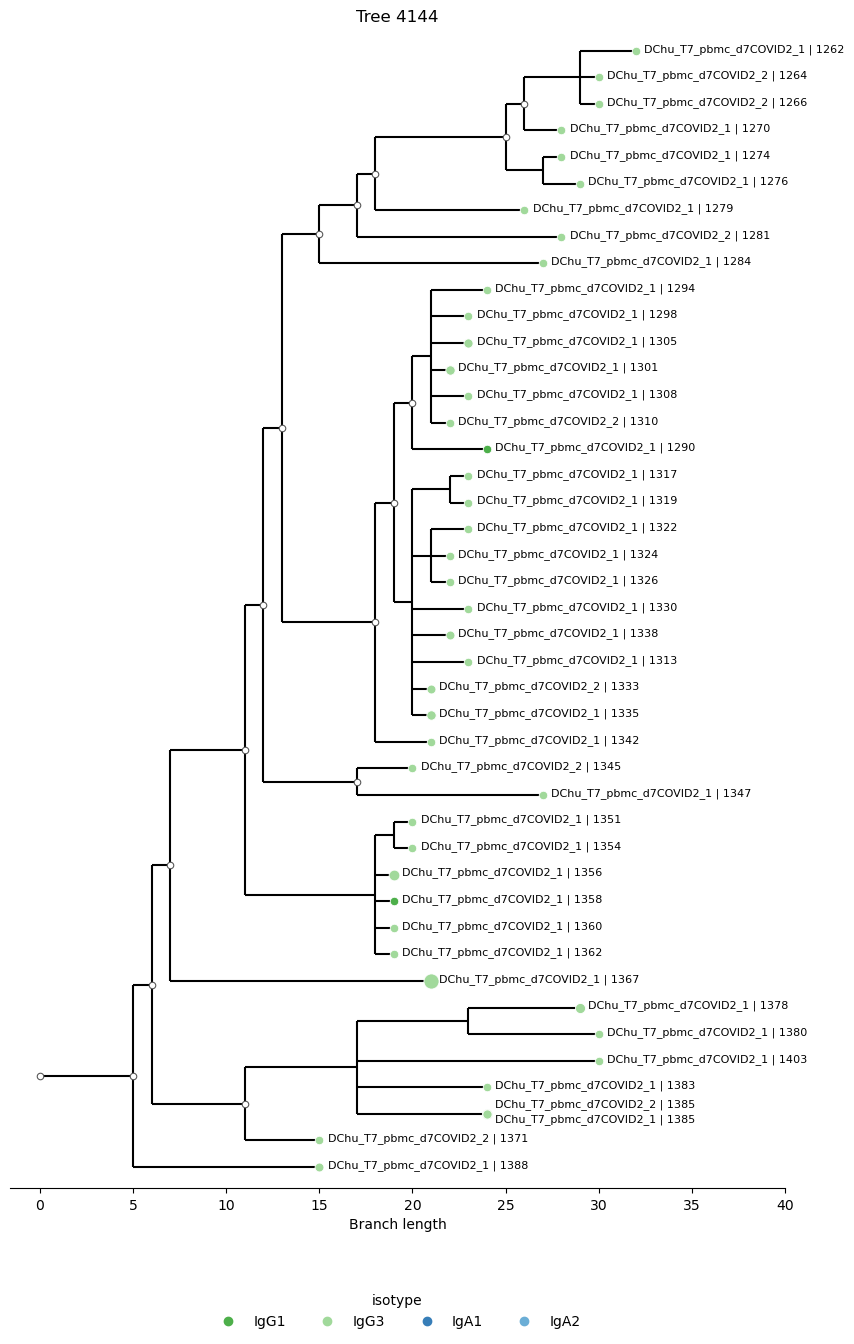

In [395]:
ta.draw_tree(4144, group="isotype", label="nodeId")

### Make logo for tree

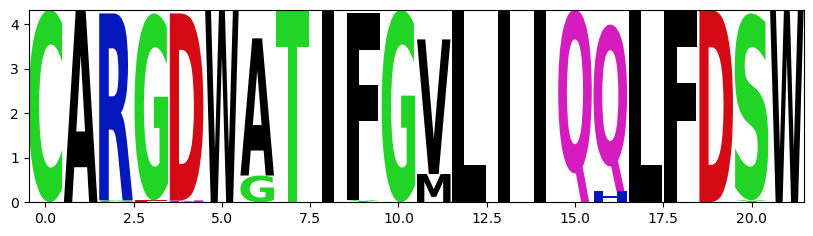

In [396]:
ta.get_logo_for_tree(4144)

### Plot mutation rates

<Axes: title={'center': 'Tree 4144 mutation frequencies'}, xlabel='Position', ylabel='Mutation frequency'>

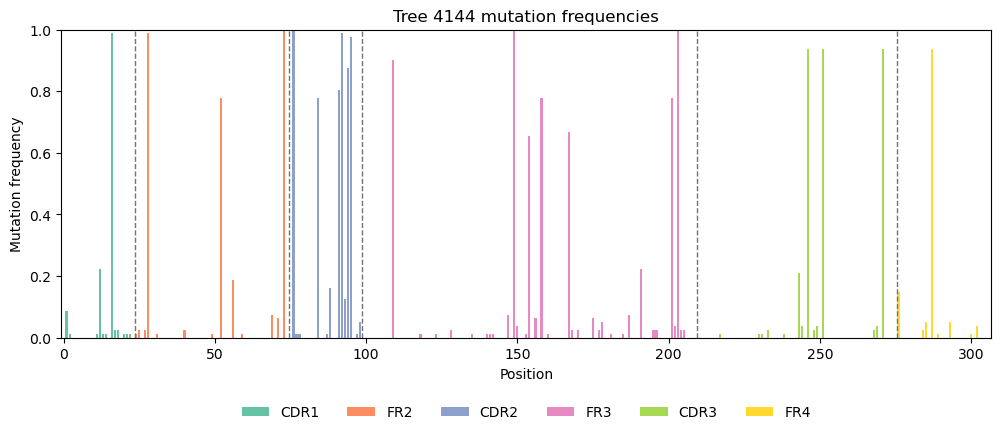

In [397]:
ta.plot_mutations_rate(4144)

### Plot timepoint trajectories

<Axes: title={'center': 'Tree 1393 timepoint trajectory'}, xlabel='timepoint', ylabel='Lineage fraction in repertoire by UMI count'>

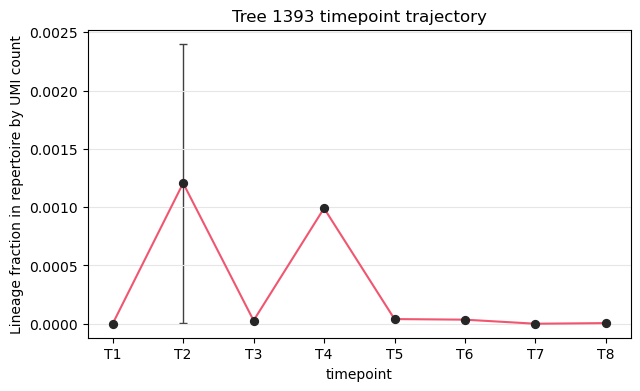

In [398]:
ta.timepoint_trajectory(1393)

### Timepoint isotypes

<Axes: title={'center': 'Tree 6909 isotypes by timepoint'}, xlabel='timepoint', ylabel='Mean isotype fraction by UMI count'>

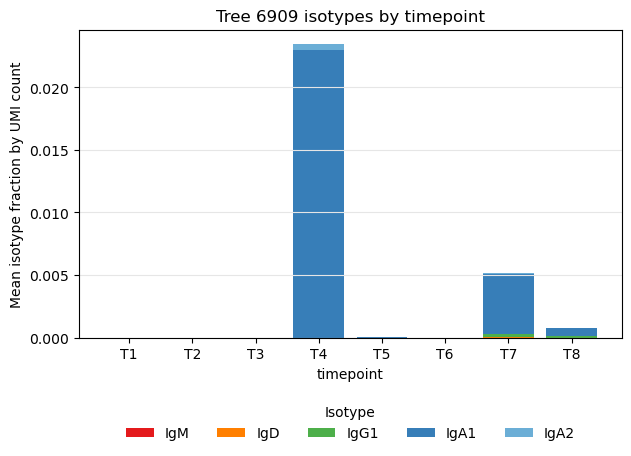

In [401]:
ta.timepoint_isotypes(6909)

### Get tree clonotypes

In [400]:
ta.get_tree_clonotypes(4144)

Pooled 302981 clonotypes from 3 samples


,treeId,sample_id,cloneId,nMutationsRate,timepoint,description,source,replica,donor_id,group,...,VEnd,DStart,DEnd,JStart,v,d,j,c,cdr3aa,cdr3nt
0,4144,DChu_T7_pbmc_d7COVID2_1,530,0.095785,T7,d7COVID2,pbmc,1,DChu,post,...,216,231,255,263,IGHV3-23,IGHD3-3,IGHJ4,IGHG3,CARGDWGTIFGMLIIQHLFDSW,TGTGCGAGGGGGGACTGGGGGACGATTTTTGGAATGCTTATCATAC...
1,4144,DChu_T7_pbmc_d7COVID2_2,544,0.095785,T7,d7COVID2,pbmc,2,DChu,post,...,216,231,255,263,IGHV3-23,IGHD3-3,IGHJ4,IGHG3,CARGDWGTIFGMLIIQHLFDSW,TGTGCGAGGGGGGACTGGGGGACGATTTTTGGAATGCTTATCATAC...
2,4144,DChu_T7_pbmc_d7COVID2_1,80950,0.107280,T7,d7COVID2,pbmc,1,DChu,post,...,216,231,255,263,IGHV3-23,IGHD3-3,IGHJ4,IGHG3,CARGDWGTIFGMLIIQHLFDSW,TGTGCGAGGGGGGACTGGGGGACGATTTTTGGAATGCTTATCATAC...
3,4144,DChu_T7_pbmc_d7COVID2_2,21333,0.099617,T7,d7COVID2,pbmc,2,DChu,post,...,216,231,255,263,IGHV3-23,IGHD3-3,IGHJ4,IGHG3,CARGDWGTIFGMLIIQHLFDSW,TGTGCGAGGGGGGACTGGGGGACGATTTTTGGAATGCTTATCATAC...
4,4144,DChu_T7_pbmc_d7COVID2_2,21334,0.099617,T7,d7COVID2,pbmc,2,DChu,post,...,216,231,255,263,IGHV3-23,IGHD3-3,IGHJ4,IGHG3,CARGDWGTIFGMLIIQHLFDSW,TGTGCGAGGGGGGACTGGGGGACGATTTTTGGAATGCTTATCATAC...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,4144,DChu_T7_pbmc_d7COVID2_1,3446,0.045977,T7,d7COVID2,pbmc,1,DChu,post,...,216,231,255,263,IGHV3-23,IGHD3-3,IGHJ4,IGHG3,CARGDWATIFGVLIIQQLFDSW,TGTGCGAGGGGGGACTGGGCGACGATTTTTGGAGTGCTTATCATAC...
77,4144,DChu_T7_pbmc_d7COVID2_2,2987,0.045977,T7,d7COVID2,pbmc,2,DChu,post,...,216,231,255,263,IGHV3-23,IGHD3-3,IGHJ4,IGHG3,CARGDWATIFGVLIIQQLFDSW,TGTGCGAGGGGGGACTGGGCGACGATTTTTGGAGTGCTTATCATAC...
78,4144,DChu_T7_pbmc_d7COVID2_1,3342,0.068966,T7,d7COVID2,pbmc,1,DChu,post,...,216,231,255,263,IGHV3-23,IGHD3-3,IGHJ4,IGHG3,CARGDWATIFGVLIIQQLFDSW,TGTGCGAGGGGGGACTGGGCGACGATTTTTGGAGTGCTTATCATAC...
79,4144,DChu_T7_pbmc_d7COVID2_1,96799,0.072797,T7,d7COVID2,pbmc,1,DChu,post,...,216,231,255,263,IGHV3-23,IGHD3-3,IGHJ4,IGHG3,CARGDWATIFGVLIIQQLFDSW,TGTGCGAGGGGGGACTGGGCGACGATTTTTGGAGTGCTTATCATAC...


### Create count table from trees_df

In [257]:
trees_count_table = ta.to_count_table()
trees_count_table["treeId"] = trees_count_table["treeId"].astype(str)
trees_count_table

,treeId,v,j,consensus_cdr3,DChu_T1_pbmc_H_1,DChu_T1_pbmc_H_2,DChu_T2_pbmc_beforeSV2_1,DChu_T2_pbmc_beforeSV2_2,DChu_T3_pbmc_preCOVID_1,DChu_T3_pbmc_preCOVID_2,DChu_T4_Bmem_postCOVID_1,DChu_T4_asc_postCOVID_1,DChu_T4_pbmc_postCOVID_1,DChu_T5_pbmc_H_1,DChu_T5_pbmc_H_2,DChu_T6_pbmc_preCOVID2_1,DChu_T6_pbmc_preCOVID2_2,DChu_T7_pbmc_d7COVID2_1,DChu_T7_pbmc_d7COVID2_2,DChu_T8_pbmc_d12COVID2_1
0,8189,IGHV3-33*01,IGHJ6*04,CARDRRTGLWSGYGYMDVW,0,0,0,0,0,0,0,0,0,0,0,1,0,23083,3447,1815
1,6909,IGHV3-30*18,IGHJ4*02,CAKLQGIFWLWQPNRAGGADYW,0,0,0,0,0,0,0,305,1,0,1,1,0,2673,386,141
2,11524,IGHV2-26*01,IGHJ6*02,CARTQKEVTIFGTFYYAMDVW,0,0,0,0,0,0,0,0,0,0,0,0,0,3137,344,446
3,6388,IGHV3-74*01-M1-F6AFPNX22I2VY7SP5EUIMV2F,IGHJ4*02,CARDLSSGYW,17,22,14,13,21,26,0,0,6,33,20,33,38,44,10,25
4,11074,IGHV2-5*02,IGHJ5*02,CAHRPGIALVGAGAFRFDPW,0,0,0,0,0,0,0,0,0,0,0,0,2,3984,543,334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20434,10428,IGHV1-46*01,IGHJ6*04,YARRPVQIGDIVVVPAAGYYYYYMDVW,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0
20435,19679,IGHV3-64*01,IGHJ4*02,YARVSTWA_EAPGQHW,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0
20436,6595,IGHV3-65*00-M2-I744NJNFGML7DHY4FVXSVID6,IGHJ3*02,YTRGGQWL_QWDSFDIW,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
20437,6603,IGHV3-65*00-M2-I744NJNFGML7DHY4FVXSVID6,IGHJ6*02,YTSECSGSYYLNYYYYYGLDVW,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0


### Find diff_enriched trees

In [258]:
prefiltered_count_table = rsde.prefilter(trees_count_table, min_samples=4, min_total_count=20, min_count=4)
prefiltered_count_table

Differential enrichment prefilter
--------------------------------------------------
Minimum samples: 4
Minimum count per sample: 4
Minimum total count: 20
Features passed: 1101 of 20439


,treeId,v,j,consensus_cdr3,prefilter_pass,DChu_T1_pbmc_H_1,DChu_T1_pbmc_H_2,DChu_T2_pbmc_beforeSV2_1,DChu_T2_pbmc_beforeSV2_2,DChu_T3_pbmc_preCOVID_1,...,DChu_T4_Bmem_postCOVID_1,DChu_T4_asc_postCOVID_1,DChu_T4_pbmc_postCOVID_1,DChu_T5_pbmc_H_1,DChu_T5_pbmc_H_2,DChu_T6_pbmc_preCOVID2_1,DChu_T6_pbmc_preCOVID2_2,DChu_T7_pbmc_d7COVID2_1,DChu_T7_pbmc_d7COVID2_2,DChu_T8_pbmc_d12COVID2_1
0,8189,IGHV3-33*01,IGHJ6*04,CARDRRTGLWSGYGYMDVW,False,0,0,0,0,0,...,0,0,0,0,0,1,0,23083,3447,1815
1,6909,IGHV3-30*18,IGHJ4*02,CAKLQGIFWLWQPNRAGGADYW,True,0,0,0,0,0,...,0,305,1,0,1,1,0,2673,386,141
2,11524,IGHV2-26*01,IGHJ6*02,CARTQKEVTIFGTFYYAMDVW,False,0,0,0,0,0,...,0,0,0,0,0,0,0,3137,344,446
3,6388,IGHV3-74*01-M1-F6AFPNX22I2VY7SP5EUIMV2F,IGHJ4*02,CARDLSSGYW,True,17,22,14,13,21,...,0,0,6,33,20,33,38,44,10,25
4,11074,IGHV2-5*02,IGHJ5*02,CAHRPGIALVGAGAFRFDPW,False,0,0,0,0,0,...,0,0,0,0,0,0,2,3984,543,334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20434,10428,IGHV1-46*01,IGHJ6*04,YARRPVQIGDIVVVPAAGYYYYYMDVW,False,0,0,0,0,0,...,0,0,0,0,0,0,0,2,0,0
20435,19679,IGHV3-64*01,IGHJ4*02,YARVSTWA_EAPGQHW,False,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
20436,6595,IGHV3-65*00-M2-I744NJNFGML7DHY4FVXSVID6,IGHJ3*02,YTRGGQWL_QWDSFDIW,False,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
20437,6603,IGHV3-65*00-M2-I744NJNFGML7DHY4FVXSVID6,IGHJ6*02,YTSECSGSYYLNYYYYYGLDVW,False,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0


In [259]:
diff_enrichment_stats = rsde.calc_statistics(
                    prefiltered_count_table,
                    metadata,
                    presence_threshold=4,
                )

Differential enrichment analysis started
--------------------------------------------------
Method: mann_whitney
Feature column: treeId
Groups detected: 2
Group 'pre' (8 samples): ['DChu_T1_pbmc_H_1', 'DChu_T1_pbmc_H_2', 'DChu_T3_pbmc_preCOVID_1', 'DChu_T3_pbmc_preCOVID_2', 'DChu_T5_pbmc_H_1', 'DChu_T5_pbmc_H_2', 'DChu_T6_pbmc_preCOVID2_1', 'DChu_T6_pbmc_preCOVID2_2']
Group 'post' (8 samples): ['DChu_T2_pbmc_beforeSV2_1', 'DChu_T2_pbmc_beforeSV2_2', 'DChu_T4_Bmem_postCOVID_1', 'DChu_T4_asc_postCOVID_1', 'DChu_T4_pbmc_postCOVID_1', 'DChu_T7_pbmc_d7COVID2_1', 'DChu_T7_pbmc_d7COVID2_2', 'DChu_T8_pbmc_d12COVID2_1']
All numeric sample columns are represented in samples_metadata.
All samples_metadata sample IDs are represented in count_table.
Prefilter applied: 1101 of 20439 features will be tested.
Analysis count threshold: 4. Values below this threshold are treated as zero for statistical calculations.
Non-zero count values replaced with zero: 39511. Original counts will be preserved in th

In [260]:
diff_enrichment_stats

,treeId,v,j,consensus_cdr3,prefilter_pass,enriched_in,method,mean_group_count,log2FC,p_val,...,DChu_T4_Bmem_postCOVID_1,DChu_T4_asc_postCOVID_1,DChu_T4_pbmc_postCOVID_1,DChu_T5_pbmc_H_1,DChu_T5_pbmc_H_2,DChu_T6_pbmc_preCOVID2_1,DChu_T6_pbmc_preCOVID2_2,DChu_T7_pbmc_d7COVID2_1,DChu_T7_pbmc_d7COVID2_2,DChu_T8_pbmc_d12COVID2_1
10,1391,IGHV3-21*01,IGHJ6*04,CARSYGIFQNMDVW,True,post,mann_whitney,886.375,3.127401,0.310468,...,3,0,1,43,12,12,15,9,0,9
119,11402,IGHV2-70*15,IGHJ6*02,CAREARNPYGMDVW,True,post,mann_whitney,685.625,5.896135,0.574873,...,0,3,0,19,10,22,0,4,0,3
1,6909,IGHV3-30*18,IGHJ4*02,CAKLQGIFWLWQPNRAGGADYW,True,post,mann_whitney,438.250,100.000000,0.032474,...,0,305,1,0,1,1,0,2673,386,141
37,17933,IGHV3-15*01,IGHJ4*02,CTTDAGKHCRGDCEEVYW,True,post,mann_whitney,366.000,100.000000,0.032474,...,0,0,303,0,0,0,0,1832,219,574
164,10602,IGHV2-5*02,IGHJ4*02,CASTQSGDFVFDSW,True,post,mann_whitney,317.125,6.662775,0.672454,...,0,0,1,1,0,4,6,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20434,10428,IGHV1-46*01,IGHJ6*04,YARRPVQIGDIVVVPAAGYYYYYMDVW,False,None,None,NaN,NaN,NaN,...,0,0,0,0,0,0,0,2,0,0
20435,19679,IGHV3-64*01,IGHJ4*02,YARVSTWA_EAPGQHW,False,None,None,NaN,NaN,NaN,...,0,0,0,0,0,2,0,0,0,0
20436,6595,IGHV3-65*00-M2-I744NJNFGML7DHY4FVXSVID6,IGHJ3*02,YTRGGQWL_QWDSFDIW,False,None,None,NaN,NaN,NaN,...,0,0,0,0,0,0,0,1,0,0
20437,6603,IGHV3-65*00-M2-I744NJNFGML7DHY4FVXSVID6,IGHJ6*02,YTSECSGSYYLNYYYYYGLDVW,False,None,None,NaN,NaN,NaN,...,0,0,0,0,0,0,2,0,0,0


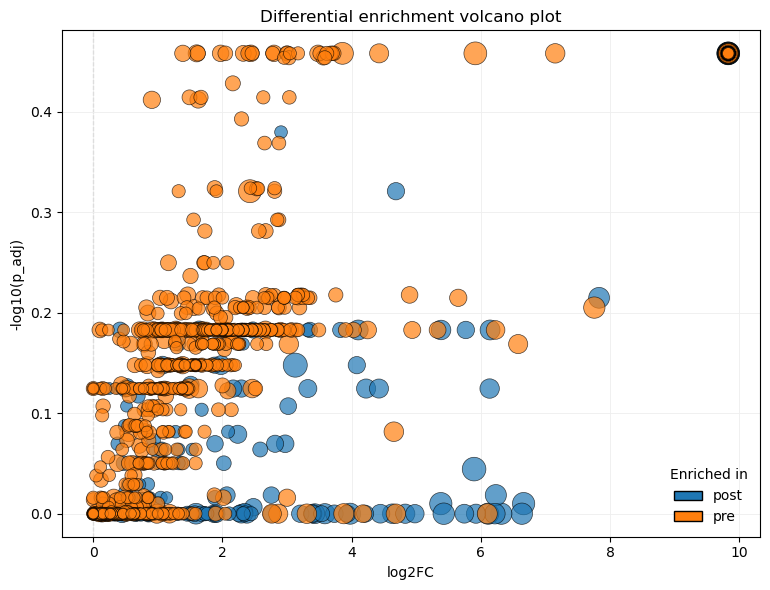

In [261]:
rsplot.de_volcano(diff_enrichment_stats)

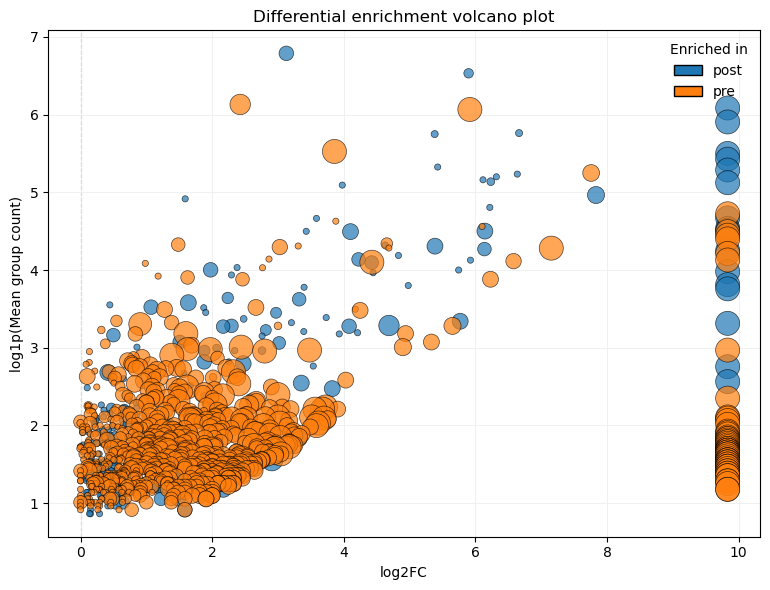

In [262]:
rsplot.de_volcano(diff_enrichment_stats, by_mean_count=True)

In [268]:
postfiltered_count_table = rsde.postfilter(diff_enrichment_stats,
                                                    groups_exclude="pre",
                                                    min_group_mean=20,
                                                    min_logfc=3,
                                                    max_p_adj=.7
                                                   )
postfiltered_count_table

Differential enrichment postfilter
--------------------------------------------------
Adjusted p-value: p_adj < 0.7
Raw p-value: any
Group mean count: mean_group_count >= 20
Log2 fold change: log2FC >= 3
Enriched-in groups: any
Excluded enriched-in groups: enriched_in not in ['pre']
Features passed prefilter: 1101 of 20439
Features passed postfilter: 20 of 1101 prefilter-passing features


,treeId,v,j,consensus_cdr3,prefilter_pass,enriched_in,method,mean_group_count,log2FC,p_val,...,DChu_T4_Bmem_postCOVID_1,DChu_T4_asc_postCOVID_1,DChu_T4_pbmc_postCOVID_1,DChu_T5_pbmc_H_1,DChu_T5_pbmc_H_2,DChu_T6_pbmc_preCOVID2_1,DChu_T6_pbmc_preCOVID2_2,DChu_T7_pbmc_d7COVID2_1,DChu_T7_pbmc_d7COVID2_2,DChu_T8_pbmc_d12COVID2_1
1,6909,IGHV3-30*18,IGHJ4*02,CAKLQGIFWLWQPNRAGGADYW,True,post,mann_whitney,438.25,100.0,0.032474,...,0,305,1,0,1,1,0,2673,386,141
37,17933,IGHV3-15*01,IGHJ4*02,CTTDAGKHCRGDCEEVYW,True,post,mann_whitney,366.00,100.0,0.032474,...,0,0,303,0,0,0,0,1832,219,574
8,13632,IGHV1-69D*28x,IGHJ4*02,CASPSELYYGPSFEDYW,True,post,mann_whitney,243.75,100.0,0.032474,...,0,0,1118,0,0,0,0,660,87,85
51,13572,IGHV1-69D*28x,IGHJ3*02,CASATVINGSPGDAFDIW,True,post,mann_whitney,226.50,100.0,0.032474,...,0,0,1012,0,0,2,0,660,31,109
196,14364,IGHV3-30-3*01,IGHJ4*02,CARDPYQFPTAMPIDYW,True,post,mann_whitney,196.75,100.0,0.032474,...,0,0,110,0,0,0,0,1228,222,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20434,10428,IGHV1-46*01,IGHJ6*04,YARRPVQIGDIVVVPAAGYYYYYMDVW,False,None,None,NaN,NaN,NaN,...,0,0,0,0,0,0,0,2,0,0
20435,19679,IGHV3-64*01,IGHJ4*02,YARVSTWA_EAPGQHW,False,None,None,NaN,NaN,NaN,...,0,0,0,0,0,2,0,0,0,0
20436,6595,IGHV3-65*00-M2-I744NJNFGML7DHY4FVXSVID6,IGHJ3*02,YTRGGQWL_QWDSFDIW,False,None,None,NaN,NaN,NaN,...,0,0,0,0,0,0,0,1,0,0
20437,6603,IGHV3-65*00-M2-I744NJNFGML7DHY4FVXSVID6,IGHJ6*02,YTSECSGSYYLNYYYYYGLDVW,False,None,None,NaN,NaN,NaN,...,0,0,0,0,0,0,2,0,0,0


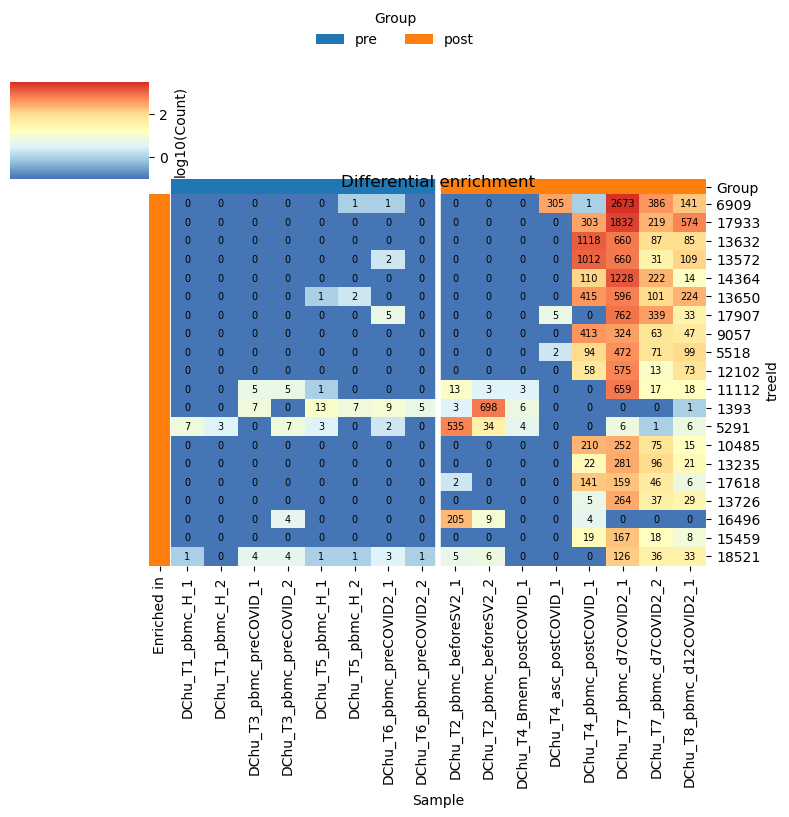

In [269]:
rsplot.de_heatmap(postfiltered_count_table, metadata, feature_column="treeId")

In [275]:
top_trees_de = postfiltered_count_table.query("postfilter_pass").treeId.astype(int)
top_trees_de

1        6909
37      17933
8       13632
51      13572
196     14364
27      13650
1505    17907
82       9057
94       5518
889     12102
1165    11112
1029     1393
321      5291
1714    10485
3235    13235
323     17618
1034    13726
1988    16496
1303    15459
324     18521
Name: treeId, dtype: int64

In [276]:
top_trees_properties = ta.trees_properties.copy()
top_trees_properties = top_trees_properties[top_trees_properties.treeId.isin(top_trees_de)]
top_trees_properties

,treeId,nodes,nodes_obs,reads,umi,isotypes,v,j,consensus_CDR3,mean_mutation_rate,isotype_switched,max_distance_from_germline
1,6909,365,268,53056,3508,"[IgA1, IgA2, IgD, IgG1, IgM]",IGHV3-30*18,IGHJ4*02,CAKLQGIFWLWQPNRAGGADYW,0.087600,True,37.0
8,13632,158,124,12111,1950,"[IgA1, IgA2, IgG1]",IGHV1-69D*28x,IGHJ4*02,CASPSELYYGPSFEDYW,0.070424,True,30.0
27,13650,91,78,8989,1339,"[IgA1, IgG1, IgG2]",IGHV1-69D*28x,IGHJ4*02,CVRDRGYSDYGATYYFDYW,0.051661,True,24.0
37,17933,89,67,18034,2928,"[IgA1, IgD, IgG1, IgM]",IGHV3-15*01,IGHJ4*02,CTTDAGKHCRGDCEEVYW,0.067164,True,34.0
51,13572,90,58,14808,1814,"[IgA1, IgD, IgG1, IgM]",IGHV1-69D*28x,IGHJ3*02,CASATVINGSPGDAFDIW,0.069288,True,34.0
82,9057,69,45,6458,847,"[IgA1, IgG1]",IGHV4-59*01,IGHJ4*02,CARWWVGDYDFWSGSSMGASYYIDYW,0.073342,True,35.0
94,5518,51,42,6007,738,"[IgA1, IgA2, IgG1]",IGHV3-64D*06,IGHJ4*02,CVKGPRTNGDYFEYW,0.041311,True,18.0
196,14364,40,32,11371,1574,"[IgA1, IgD, IgG1, IgM]",IGHV3-30-3*01,IGHJ4*02,CARDPYQFPTAMPIDYW,0.088969,True,29.0
321,5291,43,26,6325,608,[IgD],IGHV3-23*01,IGHJ6*04,CAKNVVELSGGDFFFTHMDVW,0.147743,False,47.0
323,17618,30,26,2460,354,[IgG2],IGHV3-15*01,IGHJ4*02,CSATWIDW,0.069408,True,31.0


<Axes: title={'center': 'Tree 11112'}, xlabel='Branch length'>

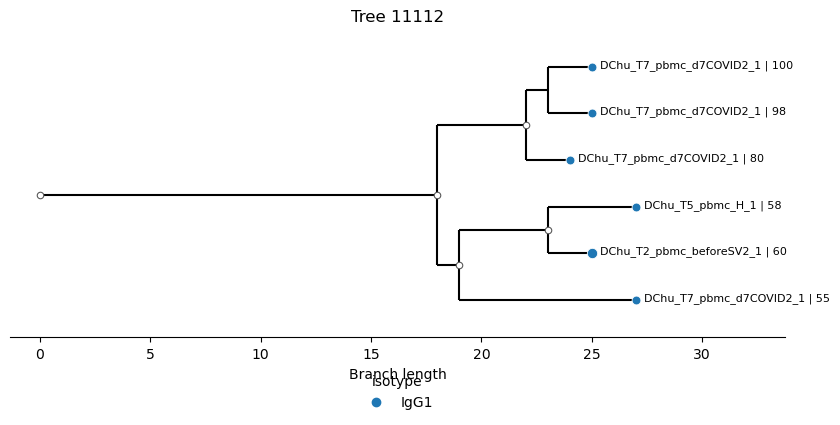

In [271]:
ta.draw_tree(11112, label="nodeId")

# Clonosets -- alleles all

## read clonosets df

In [284]:
clonosets = cl.find_all_mixcr_clonosets(MIXCR_ALLELES_DIR).merge(metadata)
clonosets = clonosets.merge(stats.calc_clonoset_stats(clonosets)).sort_values()
clonosets

Using all available worker processes by default. Set cpu=1 or another integer to change this.
CalcClonosetStats |##################################################| 16/16 calcultaion(s) processed


,sample_id,chain,filename,timepoint,description,source,replica,donor_id,group,clones,...,clones_nonfunc_freq,reads,reads_func,reads_nonfunc,reads_nonfunc_freq,umi,umi_func,umi_nonfunc,umi_nonfunc_freq,reads_per_umi
0,DChu_T7_pbmc_d7COVID2_1,IGH,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,T7,d7COVID2,pbmc,1,DChu,post,138041,...,0.028636,2873550,2840188,33362,0.011610,445549,440436,5113,0.011476,6.45
1,DChu_T6_pbmc_preCOVID2_2,IGH,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,T6,preCOVID2,pbmc,2,DChu,pre,80445,...,0.028193,1107944,1087127,20817,0.018789,167948,164874,3074,0.018303,6.60
2,DChu_T7_pbmc_d7COVID2_2,IGH,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,T7,d7COVID2,pbmc,2,DChu,post,37516,...,0.029321,716879,706820,10059,0.014032,90924,89665,1259,0.013847,7.88
3,DChu_T4_asc_postCOVID_1,IGH,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,T4,postCOVID,asc,1,DChu,post,775,...,0.024516,594303,589997,4306,0.007245,6504,6464,40,0.006150,91.38
4,DChu_T6_pbmc_preCOVID2_1,IGH,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,T6,preCOVID2,pbmc,1,DChu,pre,118669,...,0.025896,1668867,1642632,26235,0.015720,226022,222478,3544,0.015680,7.38
5,DChu_T1_pbmc_H_2,IGH,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,T1,H,pbmc,2,DChu,pre,85712,...,0.033578,3700538,3652138,48400,0.013079,263450,259833,3617,0.013729,14.05
6,DChu_T4_pbmc_postCOVID_1,IGH,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,T4,postCOVID,pbmc,1,DChu,post,28126,...,0.041421,959846,944859,14987,0.015614,87674,86320,1354,0.015444,10.95
7,DChu_T8_pbmc_d12COVID2_1,IGH,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,T8,d12COVID2,pbmc,1,DChu,post,127424,...,0.026730,2076147,2036120,40027,0.019279,189100,185458,3642,0.019260,10.98
8,DChu_T3_pbmc_preCOVID_1,IGH,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,T3,preCOVID,pbmc,1,DChu,pre,94027,...,0.029492,2752274,2717762,34512,0.012539,255235,251916,3319,0.013004,10.78
9,DChu_T1_pbmc_H_1,IGH,/home/mmyshkin/projects/repseq/bcr_trees/mixcr...,T1,H,pbmc,1,DChu,pre,65339,...,0.027487,1967952,1941021,26931,0.013685,154085,151845,2240,0.014537,12.77
